# 2.1 Spatial Data Analytics

In this notebook we analyze the extreme uneven distribution of demand throuout the whole map of chicago, especially the high number of locations with 0 demand.

In [1]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Import packages                         #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

import pandas as pd
import matplotlib.pyplot as plt
import math
import numpy as np
from scipy.stats import zscore
from shapely.geometry import Polygon, Point

import geopandas as gpd
import h3

import os

In [ ]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Reset working directory                 #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

# Depending on where the ipython kernel was started, we need to switch directories
if os.path.basename(os.getcwd()) != 'my_project':
    print(f'Dir: {os.getcwd()}')
    print('Going up a level...')
    os.chdir('..')
    print(f'Dir: {os.getcwd()}')
else:
    print(f'Already at project root: {os.getcwd()}')

In [3]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Load data                               #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

raw_data= pd.read_csv("../data/trips/STATE_01_04_trip_data_cleanup_V1.csv")

In [6]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Spatial Resolution                      #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

# Area-weighted Census Tract → H3 Mapping
# For each census tract, finds all H3 cells that overlap it and computes
# intersection-area weights (summing to 1 per tract). Trips are later
# probabilistically assigned to a hexagon based on this distribution.

_tracts_raw = gpd.read_file("../data/Census_Tracts_Chicago.geojson")
tracts = _tracts_raw.rename(columns={"census_t_1": "GEOID"}).to_crs(4326)
TRACT_COL = "GEOID"

def build_hex_coverage(tracts_gdf, res_level, tract_col=TRACT_COL):
    rows = []
    for _, row in tracts_gdf.iterrows():
        tract_id = row[tract_col]
        geom = row.geometry
        parts = list(geom.geoms) if geom.geom_type == 'MultiPolygon' else [geom]
        cells = set()
        for part in parts:
            cells.update(h3.geo_to_cells(part.__geo_interface__, res_level))
        if not cells:  # fallback for tracts smaller than one H3 cell
            c = geom.centroid
            cells = {h3.latlng_to_cell(c.y, c.x, res_level)}
        candidates = set(cells)
        for cell in cells:
            candidates.update(h3.grid_disk(cell, 1))  # expand by 1 ring to catch border cells
        for cell in candidates:
            hex_poly = Polygon([(lon, lat) for lat, lon in h3.cell_to_boundary(cell)])
            area = geom.intersection(hex_poly).area
            if area > 0:
                rows.append({'tract_id': tract_id, 'h3_cell': cell, 'area': area})
    coverage = pd.DataFrame(rows)
    total = coverage.groupby('tract_id')['area'].transform('sum')
    coverage['weight'] = coverage['area'] / total
    return coverage[['tract_id', 'h3_cell', 'weight']]

resolutions = {'low': 6, 'medium': 7, 'high': 8}

coverage = {}
for res_name, res_level in resolutions.items():
    print(f"Building {res_name} resolution (level {res_level}) …", flush=True)
    coverage[res_name] = build_hex_coverage(tracts, res_level)
    print(f"  → {len(coverage[res_name]):,} tract-cell pairs")

Building low resolution (level 6) …
  → 1,172 tract-cell pairs
Building medium resolution (level 7) …
  → 1,736 tract-cell pairs
Building high resolution (level 8) …
  → 3,650 tract-cell pairs


In [7]:
# Pinned locations override area-weighting for tracts where trips consistently
# go to one specific point (e.g. O'Hare terminal rather than the whole tract).
pinned_locations = {
    "ohare_terminal":     (41.9786, -87.9048),
    "big_marsh_entrance": (41.668,  -87.554),
}

pts = gpd.GeoDataFrame(
    {"name": list(pinned_locations.keys())},
    geometry=[Point(lon, lat) for lat, lon in pinned_locations.values()],
    crs=4326,
)
joined = gpd.sjoin(pts, tracts[[TRACT_COL, "geometry"]], how="left", predicate="within")
tract_overrides = {
    row[TRACT_COL]: [pinned_locations[row["name"]]]
    for _, row in joined.iterrows()
    if pd.notna(row[TRACT_COL])
}

print("Pinned tract overrides:")
for tid, locs in tract_overrides.items():
    print(f"  tract {tid}  →  {locs}")

# Probabilistically assign each trip to an H3 cell based on its census tract's
# area-weight distribution; pinned tracts go to their exact hexagon instead.
rng = np.random.default_rng(42)

for res_name, res_level in resolutions.items():
    lookup = {
        tid: (grp['h3_cell'].values, grp['weight'].values)
        for tid, grp in coverage[res_name].groupby('tract_id')
    }
    for tract_id, locs in tract_overrides.items():
        cells = np.array(list({h3.latlng_to_cell(lat, lon, res_level) for lat, lon in locs}))
        lookup[tract_id] = (cells, np.ones(len(cells)) / len(cells))

    for direction in ('pickup', 'dropoff'):
        tract_col_name = f'{direction}_census_tract'
        h3_col = f'{direction}_h3_{res_name}_resolution'
        result = pd.Series(index=raw_data.index, dtype=object)

        for tract_id, idx in raw_data.groupby(tract_col_name).groups.items():
            key = str(int(float(tract_id))) if pd.notna(tract_id) else None
            if key is None or key not in lookup:
                continue
            cells, weights = lookup[key]
            result[idx] = rng.choice(cells, size=len(idx), p=weights)

        raw_data[h3_col] = result

    # Fallback: assign H3 directly from coordinates for any rows still null
    # (trips whose centroid falls just outside all tract polygon boundaries)
    for direction, lat_col, lon_col in [
        ('pickup',  'pickup_centroid_latitude',  'pickup_centroid_longitude'),
        ('dropoff', 'dropoff_centroid_latitude', 'dropoff_centroid_longitude'),
    ]:
        h3_col = f'{direction}_h3_{res_name}_resolution'
        mask = raw_data[h3_col].isna()
        if mask.any():
            raw_data.loc[mask, h3_col] = [
                h3.latlng_to_cell(lat, lon, res_level)
                for lat, lon in zip(
                    raw_data.loc[mask, lat_col],
                    raw_data.loc[mask, lon_col],
                )
            ]

    pickup_na = raw_data[f'pickup_h3_{res_name}_resolution'].isna().sum()
    dropoff_na = raw_data[f'dropoff_h3_{res_name}_resolution'].isna().sum()
    print(f"{res_name}: pickup NAs={pickup_na:,}  dropoff NAs={dropoff_na:,}")


Pinned tract overrides:
  tract 17031760900  →  [(41.9786, -87.9048)]
  tract 17031510400  →  [(41.668, -87.554)]
low: pickup NAs=0  dropoff NAs=0
medium: pickup NAs=0  dropoff NAs=0
high: pickup NAs=0  dropoff NAs=0


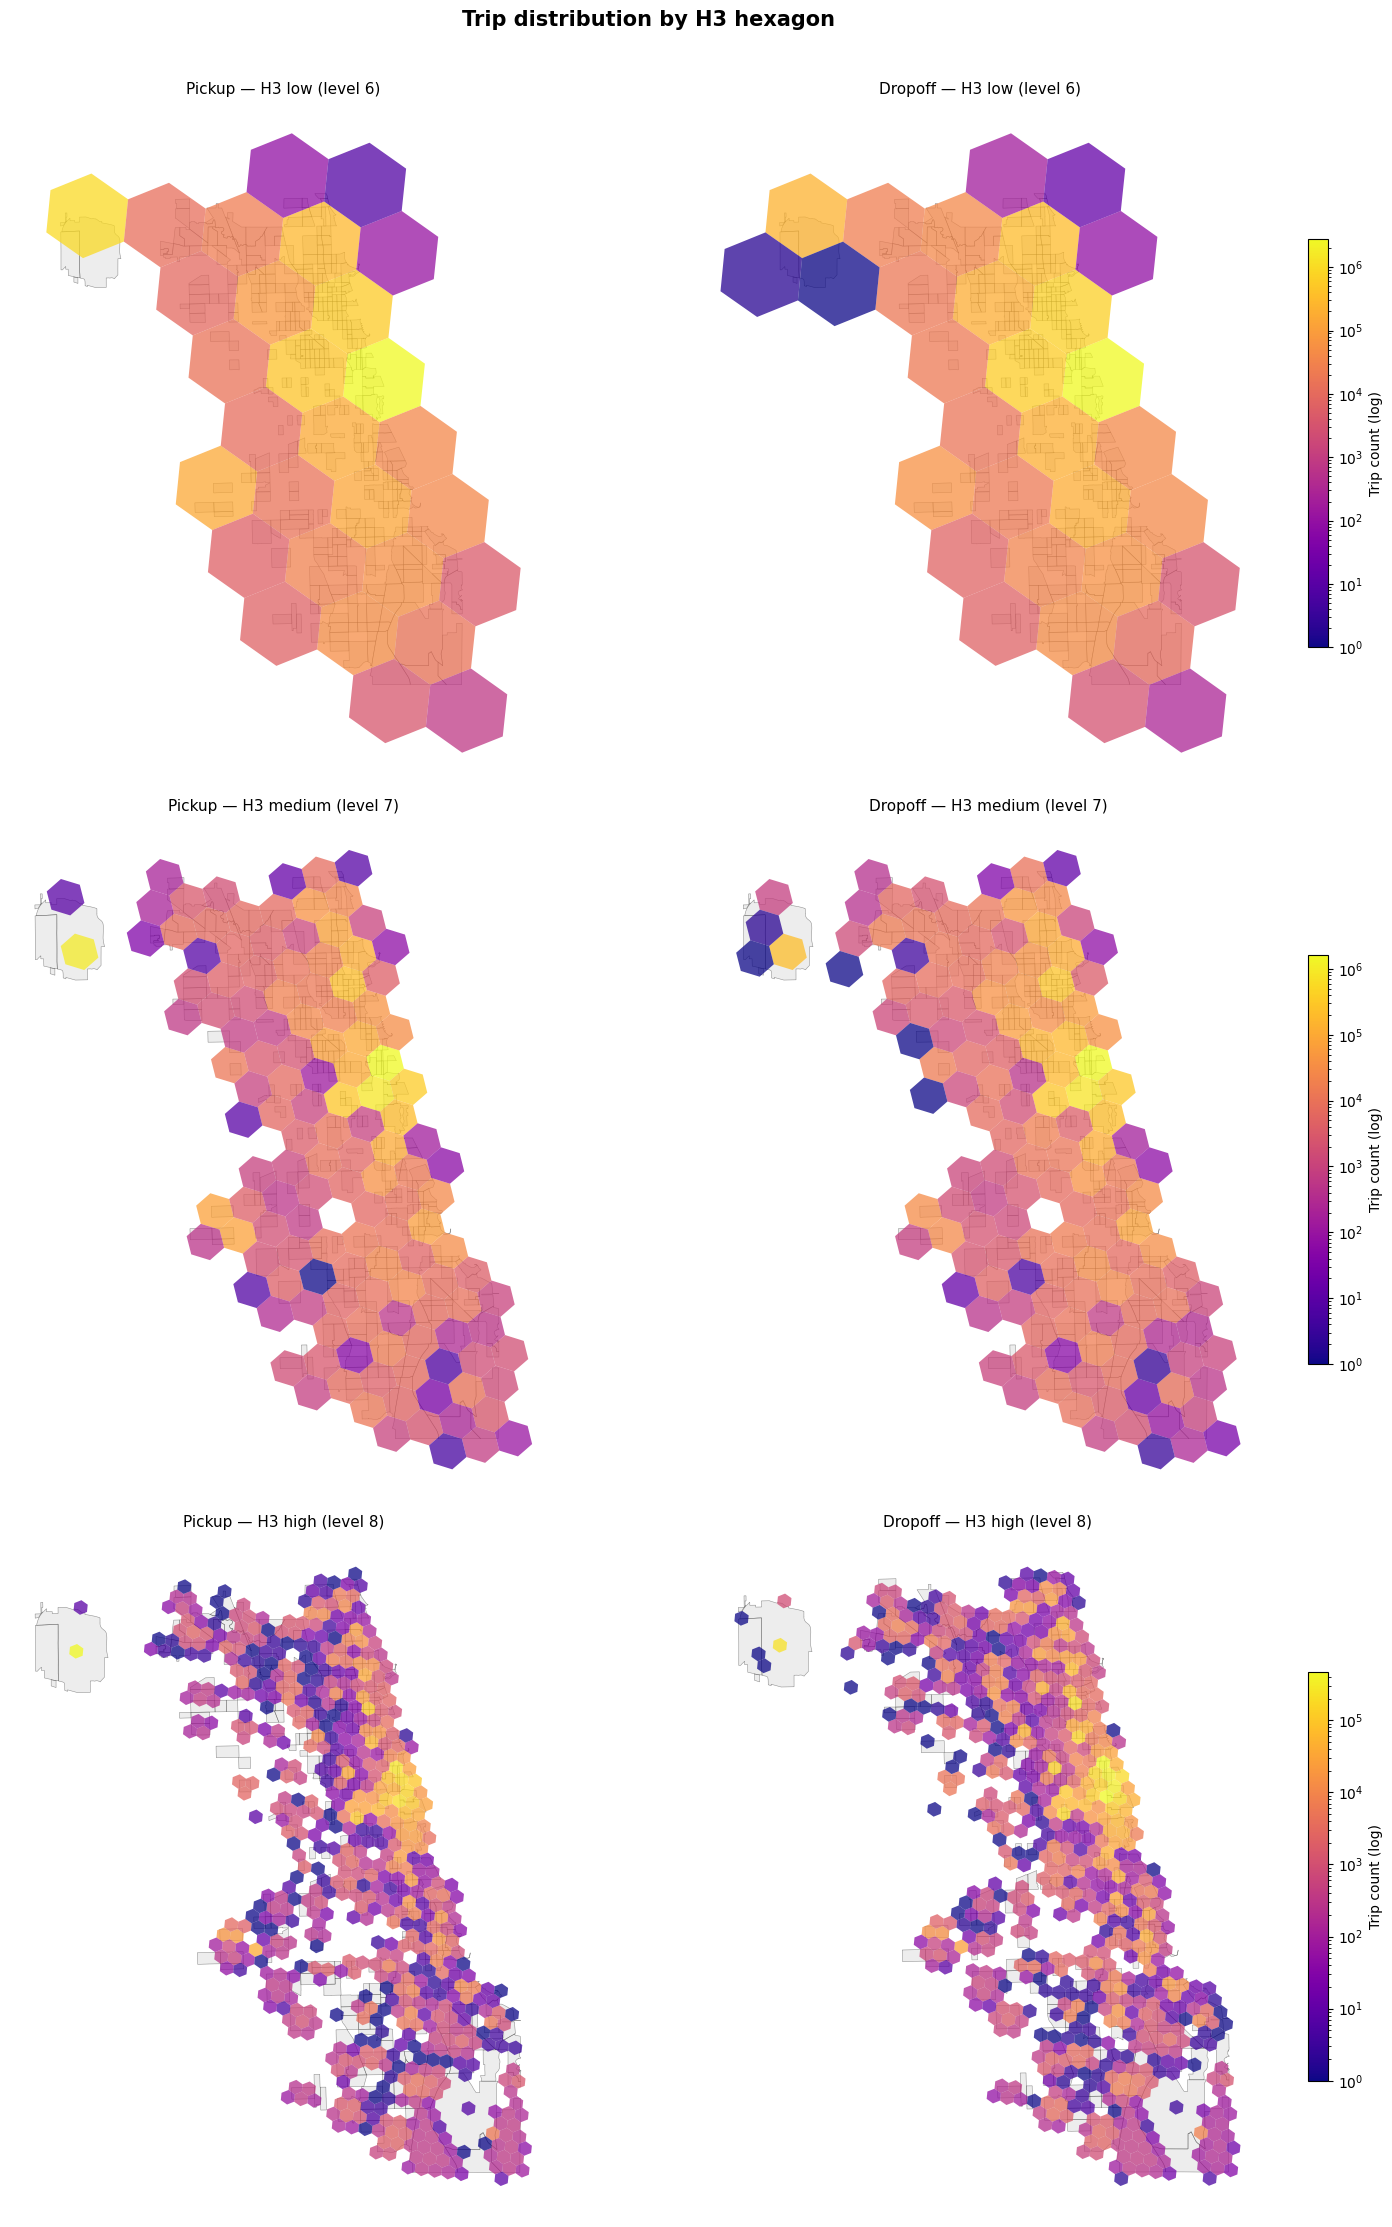

In [8]:
from matplotlib.colors import LogNorm

# Tracts that actually appear in the data (union of pickup + dropoff)
tracts_with_trips = set(
    raw_data["pickup_census_tract"].dropna().apply(lambda x: str(int(float(x))))
) | set(
    raw_data["dropoff_census_tract"].dropna().apply(lambda x: str(int(float(x))))
)
active_tracts = tracts[tracts[TRACT_COL].isin(tracts_with_trips)]

# H3 choropleths — one row per resolution, pickup / dropoff side by side
fig, axes = plt.subplots(3, 2, figsize=(16, 22))

for row_idx, (res_name, res_level) in enumerate(resolutions.items()):
    for col_idx, direction in enumerate(('pickup', 'dropoff')):
        ax = axes[row_idx, col_idx]

        counts = raw_data[f'{direction}_h3_{res_name}_resolution'].value_counts().dropna()

        # Build H3 GeoDataFrame for cells that have at least one trip
        polys = [
            Polygon([(lon, lat) for lat, lon in h3.cell_to_boundary(cell)])
            for cell in counts.index
        ]
        hex_gdf = gpd.GeoDataFrame(
            {'count': counts.values, 'geometry': polys}, crs=4326
        )

        # Base layer: only census tract outlines for tracts that have trips
        active_tracts.plot(ax=ax, facecolor='lightgray', edgecolor='black',
                           linewidth=0.4, alpha=0.4)

        # H3 layer coloured by trip count
        hex_gdf.plot(
            ax=ax, column='count', cmap='plasma',
            norm=LogNorm(vmin=1, vmax=counts.max()),
            legend=(col_idx == 1),
            legend_kwds={'label': 'Trip count (log)', 'shrink': 0.6},
            alpha=0.75, edgecolor='none'
        )

        ax.set_title(
            f'{direction.capitalize()} — H3 {res_name} (level {res_level})',
            fontsize=11
        )
        ax.set_axis_off()

plt.suptitle('Trip distribution by H3 hexagon', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()